# PS05: Lander Estimation & Control

> This notebook ports the core logic from the 2025 MATLAB PS06 helper files into Python. Most of the tuning work has been completed, available values should generally be stable and demonstrative.

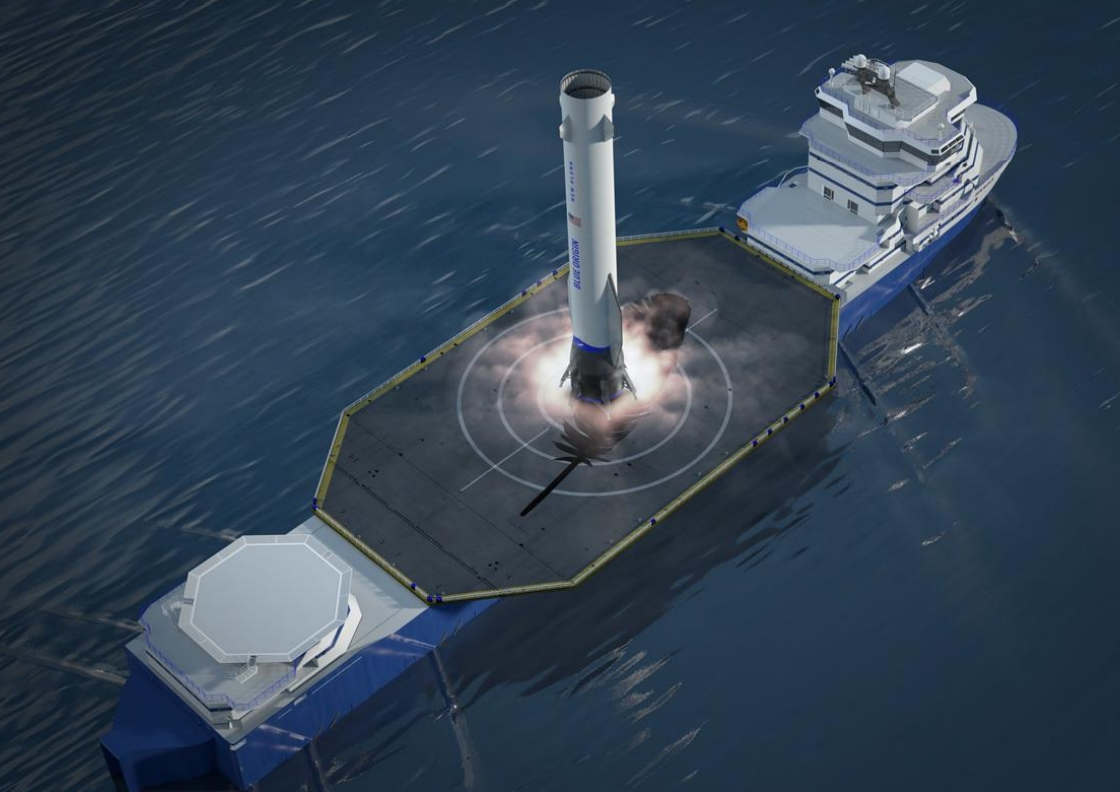

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from scipy.linalg import solve_continuous_are
from scipy.signal import place_poles

# Prefer widget backend for smooth in-notebook playback controls.
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

np.set_printoptions(precision=4, suppress=True)

## Shared Model and Utility Functions

It is not needed to understand these helper functions.

In [ ]:
#@title ⚙️ Environment Setup { display-mode: "form" }
#@hide_code
def compute_lander_shape(x_state: np.ndarray, dims: dict, phi: float):
    """Compute polygon coordinates for the lander body and nozzle line."""
    x_pos, y_pos, theta = x_state[0], x_state[2], x_state[4]

    w = dims["lander_width"]
    h = dims["lander_height"]
    lander_shape = np.array([
        [-w / 2,  w / 2,  w / 2, -w / 2, -w / 2],
        [-h / 2, -h / 2,  h / 2,  h / 2, -h / 2],
    ])

    # Keep the same sign convention as the MATLAB version.
    R = np.array([[np.cos(theta), np.sin(theta)],
                  [-np.sin(theta), np.cos(theta)]])

    lander_rot = R @ lander_shape
    lander_x = lander_rot[0, :] + x_pos
    lander_y = lander_rot[1, :] + y_pos

    nozzle_base_body = np.array([0.0, -h / 2])
    nozzle_dir_body = np.array([np.sin(phi), -np.cos(phi)])
    nozzle_tip_body = nozzle_base_body + dims["nozzle_length"] * nozzle_dir_body

    nozzle_base_rot = R @ nozzle_base_body
    nozzle_tip_rot = R @ nozzle_tip_body

    nozzle_x = np.array([nozzle_base_rot[0] + x_pos, nozzle_tip_rot[0] + x_pos])
    nozzle_y = np.array([nozzle_base_rot[1] + y_pos, nozzle_tip_rot[1] + y_pos])
    return lander_x, lander_y, nozzle_x, nozzle_y


def update_true_state(x: np.ndarray, u: np.ndarray, dt: float, m: float, I: float, g: float, l1: float):
    """Nonlinear lander dynamics integrated with forward Euler."""
    T, phi = u[0], u[1]
    theta = x[4]

    x_ddot = (T * np.sin(theta + phi)) / m
    y_ddot = (-m * g + T * np.cos(theta + phi)) / m
    theta_ddot = (T * l1 * np.sin(phi)) / I

    x_dot = np.array([x[1], x_ddot, x[3], y_ddot, x[5], theta_ddot])
    return x + dt * x_dot


def update_observer(x_hat: np.ndarray, u: np.ndarray, y_meas: np.ndarray, dt: float, A: np.ndarray, B: np.ndarray, C: np.ndarray, L: np.ndarray, g: float = 1.62):
    """Luenberger observer with gravity compensation in vertical acceleration channel."""
    gravity_term = np.array([0.0, 0.0, 0.0, g, 0.0, 0.0])
    x_hat_dot = A @ x_hat + B @ u + L @ (y_meas - C @ x_hat) - gravity_term
    return x_hat + dt * x_hat_dot


def lqr_controller(x_hat: np.ndarray, x_ref: np.ndarray, u_eq: np.ndarray, K: np.ndarray):
    """LQR tracking law: u = u_eq - K (x_hat - x_ref)."""
    return u_eq - K @ (x_hat - x_ref)


def in_zone(xp: float, yp: float, zone: dict):
    """Return true if point lies in an axis-aligned rectangle zone."""
    return (zone["x"] <= xp <= zone["x"] + zone["width"]) and (zone["y"] <= yp <= zone["y"] + zone["height"])


def check_landing(x: np.ndarray, dims: dict, safe_zone: dict, hazard_zone: dict, vel_threshold: float = 0.3):
    """Determine whether lander has landed and whether landing is safe."""
    px, py, _, _ = compute_lander_shape(x, dims, phi=0.0)
    vel = np.array([x[1], x[3]])

    landed = np.any(py <= 0.0)
    success = False

    for i in range(len(px)):
        if in_zone(float(px[i]), float(py[i]), hazard_zone):
            return True, False, vel

    all_in_safe = np.all([in_zone(float(px[i]), float(py[i]), safe_zone) for i in range(len(px))])
    if all_in_safe:
        landed = True
        success = (abs(vel[0]) < vel_threshold) and (abs(vel[1]) < vel_threshold)

    if landed and (not all_in_safe):
        success = False

    return landed, success, vel


def clamp_input(u: np.ndarray, thrust_limits=(0.0, 2.2), phi_limits=(-0.35, 0.35)):
    """Clamp actuator commands to simple physical limits."""
    T = np.clip(u[0], thrust_limits[0], thrust_limits[1])
    phi = np.clip(u[1], phi_limits[0], phi_limits[1])
    return np.array([T, phi])


def lqr_gain(A: np.ndarray, B: np.ndarray, Q: np.ndarray, R: np.ndarray):
    """Compute continuous-time LQR gain using the Riccati equation."""
    P = solve_continuous_are(A, B, Q, R)
    return np.linalg.solve(R, B.T @ P)


def observer_gain_place(A: np.ndarray, C: np.ndarray, poles):
    """Observer gain by pole placement on transposed dual system."""
    placed = place_poles(A.T, C.T, poles)
    return placed.gain_matrix.T

In [ ]:
#@title ⚙️ Environment Setup { display-mode: "form" }
#@hide_code
def run_closed_loop(
    x0: np.ndarray,
    xhat0: np.ndarray,
    x_ref: np.ndarray,
    A: np.ndarray,
    B: np.ndarray,
    C: np.ndarray,
    K: np.ndarray,
    L: np.ndarray,
    u_eq: np.ndarray,
    params: dict,
    mode: str = "full",
    ref_profile=None,
):
    """Simulate estimation/control modes with optional time-varying reference profile."""
    n_steps = int(params["t_final"] / params["dt"])
    dt = params["dt"]

    x = x0.copy()
    x_hat = xhat0.copy()

    X = np.zeros((n_steps + 1, 6))
    XH = np.zeros((n_steps + 1, 6))
    XREF = np.zeros((n_steps + 1, 6))
    U = np.zeros((n_steps + 1, 2))
    Y = np.zeros((n_steps + 1, C.shape[0]))
    t = np.linspace(0.0, params["t_final"], n_steps + 1)

    X[0] = x
    XH[0] = x_hat
    Y[0] = C @ x
    XREF[0] = x_ref.copy()

    landed = False
    success = False
    landing_idx = n_steps

    for k in range(n_steps):
        y_meas = C @ x + params["noise_std"] * np.random.randn(C.shape[0])
        Y[k] = y_meas

        if callable(ref_profile):
            x_ref_k = np.asarray(ref_profile(float(t[k]))).astype(float)
        else:
            x_ref_k = x_ref
        XREF[k] = x_ref_k

        if mode == "estimation_only":
            u = u_eq.copy()
            x_hat = update_observer(x_hat, u, y_meas, dt, A, B, C, L, g=params["g"])
        elif mode == "controller_only":
            u = lqr_controller(x, x_ref_k, u_eq, K)
            u = clamp_input(u, params["thrust_limits"], params["phi_limits"])
            x_hat = x.copy()
        else:
            u = lqr_controller(x_hat, x_ref_k, u_eq, K)
            u = clamp_input(u, params["thrust_limits"], params["phi_limits"])
            x_hat = update_observer(x_hat, u, y_meas, dt, A, B, C, L, g=params["g"])

        x = update_true_state(x, u, dt, params["m"], params["I"], params["g"], params["l1"])
        landed_now, success_now, _ = check_landing(
            x,
            params["dims"],
            params["safe_zone"],
            params["hazard_zone"],
            params["vel_threshold"],
        )
        if landed_now and (not landed):
            landed = True
            success = success_now
            landing_idx = k + 1

        X[k + 1] = x
        XH[k + 1] = x_hat
        U[k + 1] = u

        if landed and params["stop_on_landing"]:
            X = X[: k + 2]
            XH = XH[: k + 2]
            U = U[: k + 2]
            Y = Y[: k + 2]
            XREF = XREF[: k + 2]
            t = t[: k + 2]
            break

    XREF[-1] = XREF[-2] if len(XREF) > 1 else x_ref
    Y[-1] = C @ X[-1]
    return {
        "t": t,
        "X": X,
        "XH": XH,
        "XREF": XREF,
        "U": U,
        "Y": Y,
        "landed": landed,
        "success": success,
        "landing_idx": landing_idx,
    }


def plot_core_results(result: dict, title: str):
    """Compact multi-panel plot for trajectory, states, and control."""
    t = result["t"]
    X = result["X"]
    XH = result["XH"]
    U = result["U"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].plot(X[:, 0], X[:, 2], label="True trajectory")
    if "XREF" in result:
        axes[0, 0].plot(result["XREF"][:, 0], result["XREF"][:, 2], "--", lw=1.3, label="Reference")
    axes[0, 0].set_xlabel("x [m]")
    axes[0, 0].set_ylabel("y [m]")
    axes[0, 0].set_title("Position trajectory")
    axes[0, 0].grid(True)
    axes[0, 0].axis("equal")
    axes[0, 0].legend()

    axes[0, 1].plot(t, X[:, 0], label="x")
    axes[0, 1].plot(t, X[:, 2], label="y")
    axes[0, 1].plot(t, XH[:, 0], "--", label="x_hat")
    axes[0, 1].plot(t, XH[:, 2], "--", label="y_hat")
    axes[0, 1].set_title("Position and estimates")
    axes[0, 1].set_xlabel("t [s]")
    axes[0, 1].grid(True)
    axes[0, 1].legend()

    axes[1, 0].plot(t, X[:, 1], label="dx")
    axes[1, 0].plot(t, X[:, 3], label="dy")
    axes[1, 0].plot(t, X[:, 4], label="theta")
    axes[1, 0].set_title("Velocity and attitude")
    axes[1, 0].set_xlabel("t [s]")
    axes[1, 0].grid(True)
    axes[1, 0].legend()

    axes[1, 1].plot(t, U[:, 0], label="T [N]")
    axes[1, 1].plot(t, U[:, 1], label="phi [rad]")
    axes[1, 1].set_title("Control inputs")
    axes[1, 1].set_xlabel("t [s]")
    axes[1, 1].grid(True)
    axes[1, 1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_core_results_no_traj(result: dict, title: str):
    """Three-panel diagnostics used when trajectory is shown via playback animation."""
    t = result["t"]
    X = result["X"]
    XH = result["XH"]
    U = result["U"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    axes[0].plot(t, X[:, 0], label="x")
    axes[0].plot(t, X[:, 2], label="y")
    axes[0].plot(t, XH[:, 0], "--", label="x_hat")
    axes[0].plot(t, XH[:, 2], "--", label="y_hat")
    axes[0].set_title("Position and estimates")
    axes[0].set_xlabel("t [s]")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(t, X[:, 1], label="dx")
    axes[1].plot(t, X[:, 3], label="dy")
    axes[1].plot(t, X[:, 4], label="theta")
    axes[1].set_title("Velocity and attitude")
    axes[1].set_xlabel("t [s]")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(t, U[:, 0], label="T [N]")
    axes[2].plot(t, U[:, 1], label="phi [rad]")
    axes[2].set_title("Control inputs")
    axes[2].set_xlabel("t [s]")
    axes[2].grid(True)
    axes[2].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def playback_lander(
    result: dict,
    params: dict,
    title: str,
    show_estimate: bool,
    show_zones: bool,
    fixed_x_width: float | None = None,
    fixed_y_width: float | None = None,
    center_on_ref: bool = False,
):
    """Interactive playback with play/pause and frame slider."""
    t = result["t"]
    X = result["X"]
    XH = result["XH"]
    XREF = result.get("XREF", None)

    if len(t) <= 1:
        print("Simulation too short for playback.")
        return

    max_frames = 260
    stride = max(1, int(np.ceil(len(t) / max_frames)))
    idx = np.arange(0, len(t), stride)
    if idx[-1] != len(t) - 1:
        idx = np.append(idx, len(t) - 1)

    tt = t[idx]
    XX = X[idx]
    XXH = XH[idx]
    XXR = XREF[idx] if XREF is not None else None

    static_ref = False
    ref_point = None
    if XXR is not None:
        x_span_ref = float(np.max(XXR[:, 0]) - np.min(XXR[:, 0]))
        y_span_ref = float(np.max(XXR[:, 2]) - np.min(XXR[:, 2]))
        static_ref = (x_span_ref < 1e-9) and (y_span_ref < 1e-9)
        ref_point = (float(XXR[-1, 0]), float(XXR[-1, 2]))

    fig, ax = plt.subplots(figsize=(8.5, 6.0))
    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.grid(True)

    x_all = X[:, 0]
    y_all = X[:, 2]
    margin = 0.5
    xmin = float(np.min(x_all) - margin)
    xmax = float(np.max(x_all) + margin)
    ymin = min(-0.2, float(np.min(y_all) - margin))
    ymax = float(np.max(y_all) + margin)

    if show_zones:
        safe = params["safe_zone"]
        hazard = params["hazard_zone"]
        xmin = min(xmin, safe["x"] - 0.4, hazard["x"] - 0.4)
        xmax = max(xmax, safe["x"] + safe["width"] + 0.4, hazard["x"] + hazard["width"] + 0.4)
        ymax = max(ymax, hazard["y"] + hazard["height"] + 0.4)

    if (fixed_x_width is not None) and (fixed_y_width is not None):
        if center_on_ref and (ref_point is not None):
            cx, cy = ref_point
        else:
            cx = 0.5 * (xmin + xmax)
            cy = 0.5 * (ymin + ymax)
        xmin = cx - 0.5 * fixed_x_width
        xmax = cx + 0.5 * fixed_x_width
        ymin = cy - 0.5 * fixed_y_width
        ymax = cy + 0.5 * fixed_y_width

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0.0, color="gray", ls="--", lw=1.0)

    if show_zones:
        safe = params["safe_zone"]
        hazard = params["hazard_zone"]
        ax.add_patch(
            plt.Rectangle(
                (safe["x"], safe["y"]),
                safe["width"],
                safe["height"],
                alpha=0.25,
                color="green",
                label="Safe zone",
            )
        )
        ax.add_patch(
            plt.Rectangle(
                (hazard["x"], hazard["y"]),
                hazard["width"],
                hazard["height"],
                alpha=0.35,
                color="black",
                label="Hazard zone",
            )
        )

    traj_true, = ax.plot([], [], color="tab:blue", lw=1.8, label="True path")
    body_true, = ax.plot([], [], color="tab:blue", lw=2.2, label="True rocket")
    noz_true, = ax.plot([], [], color="tab:red", lw=2.0)

    if XXR is not None:
        if static_ref and (ref_point is not None):
            ref_line, = ax.plot(
                [ref_point[0]],
                [ref_point[1]],
                marker="x",
                markersize=9,
                markeredgewidth=2.0,
                linestyle="None",
                color="tab:orange",
                label="Reference",
            )
            ax.add_patch(
                plt.Circle(
                    (ref_point[0], ref_point[1]),
                    radius=0.09,
                    fill=False,
                    ec="tab:orange",
                    lw=1.2,
                    alpha=0.9,
                )
            )
        else:
            ref_line, = ax.plot(XXR[:, 0], XXR[:, 2], "--", lw=1.2, color="tab:orange", label="Reference")
    else:
        ref_line = None

    if show_estimate:
        traj_est, = ax.plot([], [], "--", color="tab:purple", lw=1.3, label="Estimated path")
        body_est, = ax.plot([], [], "--", color="tab:purple", lw=1.9, label="Estimated rocket")
        noz_est, = ax.plot([], [], "--", color="tab:pink", lw=1.4)
    else:
        traj_est = body_est = noz_est = None

    time_text = ax.text(0.02, 0.97, "", transform=ax.transAxes, va="top")
    ax.legend(loc="upper right")

    # Determine backend and canvas setup first
    backend_name = str(plt.get_backend()).lower()
    use_widget_canvas = ("ipympl" in backend_name) or ("widget" in backend_name)

    def render(frame_idx: int):
        i = int(np.clip(frame_idx, 0, len(idx) - 1))
        traj_true.set_data(XX[: i + 1, 0], XX[: i + 1, 2])

        lander_x, lander_y, nozzle_x, nozzle_y = compute_lander_shape(XX[i], params["dims"], 0.0)
        body_true.set_data(lander_x, lander_y)
        noz_true.set_data(nozzle_x, nozzle_y)

        if show_estimate:
            traj_est.set_data(XXH[: i + 1, 0], XXH[: i + 1, 2])
            est_lx, est_ly, est_nx, est_ny = compute_lander_shape(XXH[i], params["dims"], 0.0)
            body_est.set_data(est_lx, est_ly)
            noz_est.set_data(est_nx, est_ny)

        time_text.set_text(f"t = {tt[i]:.2f} s")
        fig.canvas.draw_idle()

    frame_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(idx) - 1,
        step=1,
        description="Frame",
        continuous_update=False,
        layout=widgets.Layout(width="65%"),
    )
    play = widgets.Play(
        value=0,
        min=0,
        max=len(idx) - 1,
        step=1,
        interval=35,
        description="Play",
    )
    
    # Use separate callbacks: play widget drives slider, slider drives render
    # This avoids bidirectional link interference with Play widget's auto-increment
    def _on_play_value_change(change):
        # When Play widget auto-increments, sync the slider
        frame_slider.value = change["new"]
    
    def _on_frame_change(change):
        render(change["new"])
        if not use_widget_canvas:
            with fig_out:
                fig_out.clear_output(wait=True)
                display(fig)

    play.observe(_on_play_value_change, names="value")
    frame_slider.observe(_on_frame_change, names="value")
    render(0)

    fig_out = widgets.Output()
    with fig_out:
        if use_widget_canvas:
            try:
                display(fig.canvas)
            except Exception:
                use_widget_canvas = False
                display(fig)
        else:
            display(fig)

    controls = widgets.HBox([play, frame_slider])
    display(widgets.VBox([fig_out, controls]))

    plt.show()


def plot_landing_scene(result: dict, params: dict, title: str):
    """Plot trajectory with safe/hazard zones and final lander body pose."""
    X = result["X"]
    safe = params["safe_zone"]
    hazard = params["hazard_zone"]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(X[:, 0], X[:, 2], lw=2.0, label="Trajectory")

    safe_rect = plt.Rectangle(
        (safe["x"], safe["y"]),
        safe["width"],
        safe["height"],
        alpha=0.25,
        color="green",
        label="Safe zone",
    )
    hazard_rect = plt.Rectangle(
        (hazard["x"], hazard["y"]),
        hazard["width"],
        hazard["height"],
        alpha=0.35,
        color="black",
        label="Hazard zone",
    )
    ax.add_patch(safe_rect)
    ax.add_patch(hazard_rect)

    x_final = X[-1]
    lander_x, lander_y, nozzle_x, nozzle_y = compute_lander_shape(x_final, params["dims"], 0.0)
    ax.plot(lander_x, lander_y, color="tab:blue", lw=2.0, label="Final lander")
    ax.plot(nozzle_x, nozzle_y, color="tab:red", lw=2.0, label="Nozzle")

    ax.axhline(0.0, color="gray", ls="--", lw=1.0)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
    ax.axis("equal")
    plt.show()

## Default Parameters and Linear Model

> These defaults are chosen to be conservative and stable for all four sections.

In [ ]:
#@title ⚙️ Environment Setup { display-mode: "form" }
#@hide_code
# Physical and simulation parameters
params = {
    "m": 1.0,
    "I": 0.02,
    "g": 1.62,
    "l1": 0.20,
    "dt": 0.01,
    "t_final": 25.0,
    "noise_std": 0.01,
    "vel_threshold": 0.3,
    "thrust_limits": (0.0, 2.2),
    "phi_limits": (-0.35, 0.35),
    "stop_on_landing": True,
    "dims": {"lander_width": 0.60, "lander_height": 0.35, "nozzle_length": 0.18},
    "safe_zone": {"x": -0.9, "y": 0.0, "width": 1.8, "height": 0.8},
    "hazard_zone": {"x": 1.2, "y": 0.0, "width": 0.45, "height": 2.4},
}

# Store latest metrics for optional recap.
section_metrics = {}

# State: [x, dx, y, dy, theta, dtheta]
x_ref = np.array([0.0, 0.0, 0.35, 0.0, 0.0, 0.0])
u_eq = np.array([params["m"] * params["g"], 0.0])

# Linearized model around hover (theta = 0, phi = 0, T = m g)
g = params["g"]
A = np.array([
    [0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, g, 0],
    [0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0],
], dtype=float)

B = np.array([
    [0, 0],
    [0, g],
    [0, 0],
    [1 / params["m"], 0],
    [0, 0],
    [0, params["m"] * params["g"] * params["l1"] / params["I"]],
], dtype=float)

# Measurements: x, y, theta
C = np.array([
    [1, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 0],
], dtype=float)

Q = np.diag([12.0, 2.0, 20.0, 4.0, 8.0, 2.0])
R = np.diag([0.55, 2.2])
K = lqr_gain(A, B, Q, R)

observer_poles = np.array([-3.2, -3.6, -4.0, -4.3, -4.7, -5.0])
L = observer_gain_place(A, C, observer_poles)

print("K shape:", K.shape, "L shape:", L.shape)
print("u_eq:", u_eq)

## 1) Pure Estimator Tuning

In [ ]:
x0 = np.array([0.8, -0.25, 2.1, -0.45, 0.18, -0.10])
xhat0 = np.array([0.0, 0.0, 1.2, 0.0, 0.0, 0.0])

def run_section1(obs_speed=1.0, noise_std=0.01):
    np.random.seed(5)
    plt.close("all")
    local_params = dict(params)
    local_params["noise_std"] = noise_std

    L_tuned = observer_gain_place(A, C, observer_poles * obs_speed)
    est_result = run_closed_loop(
        x0=x0,
        xhat0=xhat0,
        x_ref=x_ref,
        A=A,
        B=B,
        C=C,
        K=K,
        L=L_tuned,
        u_eq=u_eq,
        params=local_params,
        mode="estimation_only",
    )

    playback_lander(
        est_result,
        local_params,
        "Section 1 Playback: true vs estimated rocket",
        show_estimate=True,
        show_zones=False,
        fixed_x_width=5.0,
        fixed_y_width=6.0,
        center_on_ref=True,
    )
    plot_core_results_no_traj(est_result, "Section 1 Diagnostics: Estimation Only")

    err = est_result["X"] - est_result["XH"]
    err_norm = np.linalg.norm(err[:, [0, 2, 4]], axis=1)
    converged = bool(err_norm[-1] < 0.25 * err_norm[0])

    section_metrics["sec1"] = {
        "initial_err": float(err_norm[0]),
        "final_err": float(err_norm[-1]),
        "converged": converged,
    }

    print("Initial estimation error norm (x,y,theta):", float(err_norm[0]))
    print("Final estimation error norm (x,y,theta):", float(err_norm[-1]))
    print("Converged (final < 25% of initial):", converged)

sec1_obs_speed = widgets.FloatSlider(value=1.0, min=0.6, max=1.8, step=0.05, description="Obs speed", continuous_update=False)
sec1_noise = widgets.FloatSlider(value=0.01, min=0.0, max=0.05, step=0.0025, description="Noise std", continuous_update=False)

sec1_ui = widgets.VBox([sec1_obs_speed, sec1_noise])
sec1_out = widgets.interactive_output(
    run_section1,
    {
        "obs_speed": sec1_obs_speed,
        "noise_std": sec1_noise,
    },
)
display(sec1_ui, sec1_out)

## 2) Pure Controller Tuning

In [ ]:
x0_ctrl = np.array([-0.5, 0.6, 1.0, -0.8, -0.20, 0.12])
xhat0_ctrl = x0_ctrl.copy()

def run_section2(q_pos_scale=1.0, q_theta_scale=1.0, r_thrust_scale=1.0, r_phi_scale=1.0):
    np.random.seed(7)
    plt.close("all")
    Q_tuned = np.diag([
        12.0 * q_pos_scale,
        2.0,
        20.0 * q_pos_scale,
        4.0,
        8.0 * q_theta_scale,
        2.0 * q_theta_scale,
    ])
    R_tuned = np.diag([0.55 * r_thrust_scale, 2.2 * r_phi_scale])
    K_tuned = lqr_gain(A, B, Q_tuned, R_tuned)

    # Section 2 goal: hover at (x, y) = (0, 2) and do not stop on touchdown.
    x_ref_sec2 = np.array([0.0, 0.0, 2.0, 0.0, 0.0, 0.0])
    local_params = dict(params)
    local_params["stop_on_landing"] = False

    ctrl_result = run_closed_loop(
        x0=x0_ctrl,
        xhat0=xhat0_ctrl,
        x_ref=x_ref_sec2,
        A=A,
        B=B,
        C=C,
        K=K_tuned,
        L=L,
        u_eq=u_eq,
        params=local_params,
        mode="controller_only",
    )

    playback_lander(
        ctrl_result,
        local_params,
        "Section 2 Playback: controller-only rocket",
        show_estimate=False,
        show_zones=False,
        fixed_x_width=5.0,
        fixed_y_width=6.0,
        center_on_ref=True,
    )
    plot_core_results_no_traj(ctrl_result, "Section 2 Diagnostics: Controller Only")

    state_err = np.linalg.norm(ctrl_result["X"][-1] - x_ref_sec2)
    peak_thrust = float(np.max(ctrl_result["U"][:, 0]))
    peak_phi = float(np.max(np.abs(ctrl_result["U"][:, 1])))
    stable_like = bool(state_err < 0.8)

    section_metrics["sec2"] = {
        "final_state_err": float(state_err),
        "peak_thrust": peak_thrust,
        "peak_phi": peak_phi,
        "stable_like": stable_like,
    }

    print("Section 2 target [x, y]:", [float(x_ref_sec2[0]), float(x_ref_sec2[2])])
    print("Final state error norm:", float(state_err))
    print("Peak thrust [N]:", peak_thrust)
    print("Peak |phi| [rad]:", peak_phi)
    print("Controller stable-looking (error < 0.8):", stable_like)

sec2_qpos = widgets.FloatSlider(value=1.0, min=0.4, max=2.5, step=0.05, description="Q pos x/y", continuous_update=False)
sec2_qtheta = widgets.FloatSlider(value=1.0, min=0.4, max=2.5, step=0.05, description="Q theta", continuous_update=False)
sec2_rT = widgets.FloatSlider(value=1.0, min=0.4, max=2.5, step=0.05, description="R thrust", continuous_update=False)
sec2_rphi = widgets.FloatSlider(value=1.0, min=0.4, max=2.5, step=0.05, description="R phi", continuous_update=False)

sec2_ui = widgets.VBox([sec2_qpos, sec2_qtheta, sec2_rT, sec2_rphi])
sec2_out = widgets.interactive_output(
    run_section2,
    {
        "q_pos_scale": sec2_qpos,
        "q_theta_scale": sec2_qtheta,
        "r_thrust_scale": sec2_rT,
        "r_phi_scale": sec2_rphi,
    },
)
display(sec2_ui, sec2_out)

## 3) Controller + Estimator Tuning

In [ ]:
x0_full = np.array([-1.4, 0.5, 3.0, -0.65, 0.22, -0.15])
xhat0_full = np.array([-0.4, 0.0, 2.4, 0.0, 0.0, 0.0])

def run_section3(ctrl_aggr=1.0, obs_speed=1.0, noise_std=0.01):
    np.random.seed(11)
    plt.close("all")
    local_params = dict(params)
    local_params["noise_std"] = noise_std
    local_params["stop_on_landing"] = False

    # Section 3 goal: track hover at (x, y) = (0, 2).
    x_ref_sec3 = np.array([0.0, 0.0, 2.0, 0.0, 0.0, 0.0])

    Q_tuned = Q * ctrl_aggr
    R_tuned = R
    K_tuned = lqr_gain(A, B, Q_tuned, R_tuned)
    L_tuned = observer_gain_place(A, C, observer_poles * obs_speed)

    full_result = run_closed_loop(
        x0=x0_full,
        xhat0=xhat0_full,
        x_ref=x_ref_sec3,
        A=A,
        B=B,
        C=C,
        K=K_tuned,
        L=L_tuned,
        u_eq=u_eq,
        params=local_params,
        mode="full",
    )

    playback_lander(
        full_result,
        local_params,
        "Section 3 Playback: real and estimated rocket",
        show_estimate=True,
        show_zones=False,
        fixed_x_width=5.0,
        fixed_y_width=6.0,
        center_on_ref=True,
    )
    plot_core_results_no_traj(full_result, "Section 3 Diagnostics: Estimation + Controller")

    full_err = np.linalg.norm(full_result["X"][-1] - x_ref_sec3)
    est_err = np.linalg.norm(full_result["X"][-1] - full_result["XH"][-1])
    stable_like = bool(full_err < 1.0)

    section_metrics["sec3"] = {
        "final_tracking_err": float(full_err),
        "final_estimation_err": float(est_err),
        "stable_like": stable_like,
    }

    print("Section 3 target [x, y]:", [float(x_ref_sec3[0]), float(x_ref_sec3[2])])
    print("Final tracking error norm:", float(full_err))
    print("Final estimation mismatch norm:", float(est_err))
    print("Combined loop stable-looking (tracking error < 1.0):", stable_like)

sec3_ctrl = widgets.FloatSlider(value=1.0, min=0.5, max=2.0, step=0.05, description="Ctrl aggr", continuous_update=False)
sec3_obs = widgets.FloatSlider(value=1.0, min=0.6, max=1.8, step=0.05, description="Obs speed", continuous_update=False)
sec3_noise = widgets.FloatSlider(value=0.01, min=0.0, max=0.05, step=0.0025, description="Noise std", continuous_update=False)

sec3_ui = widgets.VBox([sec3_ctrl, sec3_obs, sec3_noise])
sec3_out = widgets.interactive_output(
    run_section3,
    {
        "ctrl_aggr": sec3_ctrl,
        "obs_speed": sec3_obs,
        "noise_std": sec3_noise,
    },
)
display(sec3_ui, sec3_out)

## 4) Full Landing

In [ ]:
# Section 4 scenario defaults: harder entry, tower obstacle, and landing zone left of tower.
base_complex_params = dict(params)
base_complex_params.update({
    "t_final": 45.0,
    "noise_std": 0.012,
    "stop_on_landing": False,
    "safe_zone": {"x": 0.30, "y": 0.0, "width": 1.20, "height": 0.95},
    "hazard_zone": {"x": 1.80, "y": 0.0, "width": 0.45, "height": 2.90},
})

# Start top-left with strong down-right diagonal velocity.
x0_complex = np.array([-3.6, 1.85, 4.8, -2.10, 0.22, -0.14])
xhat0_complex = np.array([-3.0, 1.35, 4.2, -1.45, 0.05, 0.0])

def smooth_profile_factory(
    x_start,
    y_start,
    x_goal,
    y_goal,
    t_ref=20.0,
    initial_speed_target=None,
    final_speed_target=0.10,
):
    """Create a fast-start, top-down curved reference with strong flare near landing."""
    t_ref = max(2.0, float(t_ref))

    p0 = np.array([float(x_start), float(y_start)], dtype=float)
    p3 = np.array([float(x_goal), float(y_goal)], dtype=float)

    dx = p3[0] - p0[0]
    dy = p3[1] - p0[1]
    vertical_span = max(1.0, abs(dy))
    descend_sign = -1.0 if dy <= 0.0 else 1.0

    # Shape controls: start mostly descending from above, end almost vertical over the landing zone.
    p1 = np.array([
        p0[0] + 0.08 * dx,
        p0[1] + descend_sign * 0.55 * vertical_span,
    ], dtype=float)
    p2 = np.array([
        p3[0] - 0.05 * dx,
        p3[1] - descend_sign * 0.75 * vertical_span,
    ], dtype=float)

    def _bezier_point(s):
        u = 1.0 - s
        return (
            (u**3) * p0
            + 3.0 * (u**2) * s * p1
            + 3.0 * u * (s**2) * p2
            + (s**3) * p3
        )

    def _bezier_tangent(s):
        u = 1.0 - s
        return (
            3.0 * (u**2) * (p1 - p0)
            + 6.0 * u * s * (p2 - p1)
            + 3.0 * (s**2) * (p3 - p2)
        )

    d0 = float(np.linalg.norm(_bezier_tangent(0.0)))

    entry_like = 0.9 if initial_speed_target is None else float(initial_speed_target)
    desired_v0 = max(0.9, entry_like)

    flare_power = 1.45
    target_dsdt0 = desired_v0 / max(d0, 1e-9)
    target_base_dsdt0 = target_dsdt0 / flare_power

    def _base_dsdt0(alpha):
        den = (1.0 - np.exp(-alpha)) * t_ref
        return alpha / max(den, 1e-9)

    alpha = 14.0
    for a in np.linspace(0.25, 14.0, 450):
        if _base_dsdt0(float(a)) >= target_base_dsdt0:
            alpha = float(a)
            break

    exp_den = max(1e-9, 1.0 - np.exp(-alpha))

    def _progress_and_rate(t):
        tau = float(np.clip(t / t_ref, 0.0, 1.0))
        if tau >= 1.0:
            return 1.0, 0.0

        base = (1.0 - np.exp(-alpha * tau)) / exp_den
        base_rate = (alpha * np.exp(-alpha * tau)) / (exp_den * t_ref)

        # Flare near touchdown: preserves fast start, then decays speed strongly close to the target.
        s = 1.0 - (1.0 - base) ** flare_power
        dsdt = flare_power * ((1.0 - base) ** (flare_power - 1.0)) * base_rate
        return s, dsdt

    def profile(t):
        s, dsdt = _progress_and_rate(t)
        pos = _bezier_point(s)
        vel = _bezier_tangent(s) * dsdt
        return np.array([pos[0], vel[0], pos[1], vel[1], 0.0, 0.0], dtype=float)

    # Optional diagnostic values used for sanity checking during tuning.
    v1_mag = float(np.linalg.norm(_bezier_tangent(0.999) * _progress_and_rate(0.999 * t_ref)[1]))
    if v1_mag > float(final_speed_target):
        print("Note: final reference speed is above target, consider increasing t_ref or flare.")

    return profile


def run_section4(ctrl_aggr=1.15, obs_speed=1.00, entry_speed_scale=1.0):
    np.random.seed(19)
    plt.close("all")

    local_params = dict(base_complex_params)

    # Combined tuning knobs for the hard landing scenario.
    K_tuned = lqr_gain(A, B, Q * ctrl_aggr, R)
    L_tuned = observer_gain_place(A, C, observer_poles * obs_speed)

    x0_c = x0_complex.copy()
    xhat0_c = xhat0_complex.copy()
    x0_c[1] *= 0.3 * entry_speed_scale
    x0_c[3] *= 0.3 * entry_speed_scale
    xhat0_c[1] *= 0.3 * entry_speed_scale
    xhat0_c[3] *= 0.3 * entry_speed_scale

    safe = local_params["safe_zone"]
    target_x = safe["x"] + 0.50 * safe["width"]
    target_y = 0.32

    entry_speed_mag = float(np.linalg.norm([x0_c[1], x0_c[3]]))
    desired_initial_ref_speed = 1.15 * entry_speed_mag

    ref_profile = smooth_profile_factory(
        x_start=float(x0_c[0]),
        y_start=float(x0_c[2]),
        x_goal=float(target_x),
        y_goal=float(target_y),
        t_ref=20.0,
        initial_speed_target=desired_initial_ref_speed,
        final_speed_target=0.10,
    )
    x_ref_sec4 = np.asarray(ref_profile(local_params["t_final"]), dtype=float)
    ref_init_speed_mag = float(np.linalg.norm(np.asarray(ref_profile(0.0), dtype=float)[[1, 3]]))

    sec4_result = run_closed_loop(
        x0=x0_c,
        xhat0=xhat0_c,
        x_ref=x_ref_sec4,
        A=A,
        B=B,
        C=C,
        K=K_tuned,
        L=L_tuned,
        u_eq=u_eq,
        params=local_params,
        mode="full",
        ref_profile=ref_profile,
    )

    # Show playback first so controls appear at the top of Section 4 output.
    playback_lander(
        sec4_result,
        local_params,
        "Section 4 Playback: smooth trajectory + tower + landing zone",
        show_estimate=True,
        show_zones=True,
        fixed_x_width=8.0,
        fixed_y_width=6.3,
        center_on_ref=False,
    )

    # Render diagnostics in dedicated output boxes so they always appear after playback.
    sec4_diag_out = widgets.Output()
    sec4_scene_out = widgets.Output()
    with sec4_diag_out:
        plot_core_results(sec4_result, "Section 4 Diagnostics: Full Combined Scenario")
    with sec4_scene_out:
        plot_landing_scene(sec4_result, local_params, "Section 4 Final Scene")
    display(sec4_diag_out, sec4_scene_out)

    X = sec4_result["X"]
    final_state = X[-1]
    touched = bool(sec4_result["landed"])
    safe_landing = bool(sec4_result["success"])

    # Clearance > 0 means the rocket body stays fully left of the tower's left wall.
    hazard_x = local_params["hazard_zone"]["x"]
    clearances = []
    for xk in X:
        px, _, _, _ = compute_lander_shape(xk, local_params["dims"], 0.0)
        clearances.append(hazard_x - float(np.max(px)))
    min_clearance = float(np.min(clearances))

    final_tracking_err = float(np.linalg.norm(final_state - np.asarray(ref_profile(sec4_result["t"][-1]), dtype=float)))

    section_metrics["sec4"] = {
        "touched_down_or_zone_contact": touched,
        "safe_landing": safe_landing,
        "final_velocity": [float(final_state[1]), float(final_state[3])],
        "final_tracking_err": final_tracking_err,
        "min_tower_clearance": min_clearance,
        "entry_speed_mag": entry_speed_mag,
        "ref_initial_speed_mag": ref_init_speed_mag,
    }

    print("Section 4 entry state [x, y, dx, dy]:", [float(x0_c[0]), float(x0_c[2]), float(x0_c[1]), float(x0_c[3])])
    print("Landing target [x, y]:", [float(target_x), float(target_y)])
    print("Entry speed magnitude [m/s]:", entry_speed_mag)
    print("Reference initial speed magnitude [m/s]:", ref_init_speed_mag)
    print("Touchdown/zone contact detected:", touched)
    print("Safe landing verdict:", safe_landing)
    print("Final velocity [dx, dy] [m/s]:", section_metrics["sec4"]["final_velocity"])
    print("Final tracking error norm:", final_tracking_err)
    print("Minimum tower clearance [m] (positive is safer):", min_clearance)


sec4_ctrl = widgets.FloatSlider(value=1.15, min=0.70, max=2.00, step=0.05, description="Ctrl aggr", continuous_update=False)
sec4_obs = widgets.FloatSlider(value=1.00, min=0.70, max=1.80, step=0.05, description="Obs speed", continuous_update=False)
sec4_vel = widgets.FloatSlider(value=1.00, min=0.70, max=1.30, step=0.025, description="Entry speed", continuous_update=False)

sec4_ui = widgets.VBox([sec4_ctrl, sec4_obs, sec4_vel])
sec4_out = widgets.interactive_output(
    run_section4,
    {
        "ctrl_aggr": sec4_ctrl,
        "obs_speed": sec4_obs,
        "entry_speed_scale": sec4_vel,
    },
)
display(sec4_ui, sec4_out)